# OCR Test

Test TrOCR on handwritten text samples and inspect recognition quality. (Pranav)

/Users/pranav/Desktop/inkTeX/backend/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Source image: 001a.png
Recognized text: 'that being influenced just more expensive'
Confidence: 0.471


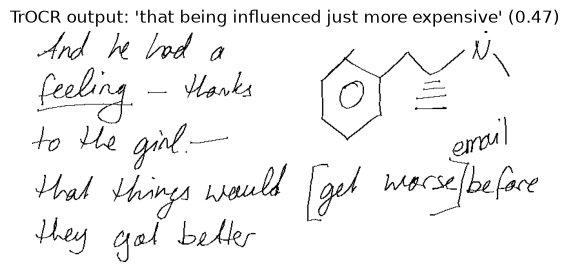

In [1]:
import sys
sys.path.insert(0, "../backend")

from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

from app.services.text_ocr import TextOcr

DATA_DIR = Path("../backend/data/layout_processed/val")
image_path = sorted(DATA_DIR.glob("images/*.png"))[0]
label_path = DATA_DIR / "labels" / (image_path.stem + ".txt")

image = Image.open(image_path)
w, h = image.size

# Grab the first ground-truth text-class (0) box to crop a real handwritten text region.
with open(label_path) as f:
    for line in f:
        cls, cx, cy, bw, bh = map(float, line.split())
        if int(cls) == 0:
            x1, y1 = (cx - bw / 2) * w, (cy - bh / 2) * h
            x2, y2 = (cx + bw / 2) * w, (cy + bh / 2) * h
            break

crop = image.crop((x1, y1, x2, y2))

ocr = TextOcr("microsoft/trocr-base-handwritten", device="cpu")
text, confidence = ocr.recognize(crop)

print(f"Source image: {image_path.name}")
print(f"Recognized text: {text!r}")
print(f"Confidence: {confidence:.3f}")

plt.figure(figsize=(8, 3))
plt.imshow(crop, cmap="gray")
plt.axis("off")
plt.title(f"TrOCR output: {text!r} ({confidence:.2f})")
plt.show()